# Lecture 4 Exercise: Function Approximation: From Linear Models to Deep RL

---

## Learning Objectives

By the end of this exercise, you will be able to:

1. **Implement linear function approximation** with semi-gradient TD(0)
2. **Understand the deadly triad** and why function approximation can diverge
3. **Build a simple Deep Q-Network (DQN)** using PyTorch
4. **Apply stabilization techniques** (experience replay, target networks)

---

## Outline

| Part | Topic | Time |
|------|-------|------|
| 1 | Linear Function Approximation & Semi-gradient TD | 15 min |
| 2 | The Deadly Triad: When Things Go Wrong | 10 min |
| 3 | Deep RL: Neural Network Function Approximation | 20 min |
| 4 | Stabilization Methods | 15 min |


## Setup

Run the cell below to import necessary libraries and set up the environment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import random
from typing import Tuple, List, Optional
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Using device: cuda


---

## Part 1: Linear Function Approximation & Semi-gradient TD (15 min)

## Background

When the state space is large (or continuous), we cannot store a value for every state. Instead, we **approximate** the value function:

$$\hat{v}(s, \mathbf{w}) \approx v_\pi(s)$$

For **linear function approximation**, we use:

$$\hat{v}(s, \mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s) = \sum_{i=1}^{d} w_i x_i(s)$$

where $\mathbf{x}(s)$ is a **feature vector** representing state $s$.

### Semi-gradient TD(0) Update

The semi-gradient TD(0) update rule is:

$$\mathbf{w} \leftarrow \mathbf{w} + \alpha \left[ R + \gamma \hat{v}(S', \mathbf{w}) - \hat{v}(S, \mathbf{w}) \right] \nabla_\mathbf{w} \hat{v}(S, \mathbf{w})$$

For linear function approximation: $\nabla_\mathbf{w} \hat{v}(S, \mathbf{w}) = \mathbf{x}(S)$

---

## Environment: Random Walk

We'll use a classic **100-state Random Walk** problem where:
- States: $1, 2, \ldots, 100$
- Terminal states: $0$ (left) and $101$ (right)
- Actions: Move left or right with step size $\in [1, \text{step\_range}]$ (random policy)
- Rewards: $-1$ for left terminal, $+1$ for right terminal, $0$ otherwise
- **Step range = 20:** This produces episodes of moderate length (~50-100 steps), giving the agent enough intermediate state visits to clearly differentiate between coarse and fine feature representations.

In [32]:
class RandomWalk:
    """100-state Random Walk environment."""
    
    def __init__(self, n_states: int = 100, step_range: int = 20):
        self.n_states = n_states
        self.step_range = step_range  # Max steps left or right
        self.state = None
        
    def reset(self) -> int:
        """Reset to center state."""
        self.state = self.n_states // 2
        return self.state
    
    def step(self) -> Tuple[int, float, bool]:
        """Take a random step."""
        # Random step size in [-step_range, step_range], excluding 0
        step = np.random.randint(1, self.step_range + 1)
        if np.random.random() < 0.5:
            step = -step
        
        self.state += step
        
        # Check terminal conditions
        if self.state <= 0:
            return 0, -1.0, True  # Left terminal
        elif self.state > self.n_states:
            return self.n_states + 1, 1.0, True  # Right terminal
        else:
            return self.state, 0.0, False

# Test the environment
env = RandomWalk()
state = env.reset()
print(f"Initial state: {state}")
for _ in range(3):
    next_state, reward, done = env.step()
    print(f"Next state: {next_state}, Reward: {reward}, Done: {done}")
    if done:
        break

Initial state: 50
Next state: 42, Reward: 0.0, Done: False
Next state: 32, Reward: 0.0, Done: False
Next state: 27, Reward: 0.0, Done: False


### True Value Function

For the random walk, the true value function is approximately linear:

$$v_\pi(s) \approx \frac{s - 50.5}{50.5}$$

This gives us a ground truth to compare against.

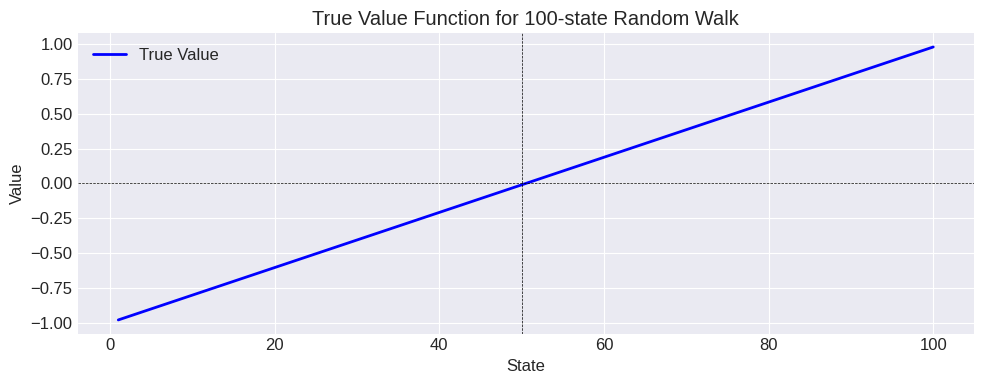

In [33]:
def true_value(n_states: int = 100) -> np.ndarray:
    """Compute the true value function for the random walk."""
    # Approximate true values (linear interpolation between -1 and 1)
    states = np.arange(1, n_states + 1)
    return (states - (n_states + 1) / 2) / ((n_states + 1) / 2)

# Compute and plot true values
true_values = true_value()
plt.figure(figsize=(10, 4))
plt.plot(range(1, 101), true_values, 'b-', linewidth=2, label='True Value')
plt.axhline(0., color='k', linewidth=0.5, linestyle='--')
plt.axvline(50., color='k', linewidth=0.5, linestyle='--')
plt.xlabel('State')
plt.ylabel('Value')
plt.title('True Value Function for 100-state Random Walk')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Representation: State Aggregation

We'll use **state aggregation** as our feature representation: group states into `n_groups` bins, creating a one-hot feature vector.

For example, with 10 groups:
- States 1-10 → feature vector `[1, 0, 0, ..., 0]`
- States 11-20 → feature vector `[0, 1, 0, ..., 0]`
- etc.

In [34]:
class StateAggregation:
    """State aggregation feature representation."""
    
    def __init__(self, n_states: int = 100, n_groups: int = 10):
        self.n_states = n_states
        self.n_groups = n_groups
        self.group_size = n_states // n_groups
        
    def features(self, state: int) -> np.ndarray:
        """Return one-hot feature vector for the given state."""
        x = np.zeros(self.n_groups)
        if 1 <= state <= self.n_states:
            group_idx = min((state - 1) // self.group_size, self.n_groups - 1)
            x[group_idx] = 1.0
        return x
    
    @property
    def dim(self) -> int:
        """Feature dimension."""
        return self.n_groups

# Test feature representation
feat = StateAggregation(n_groups=10)
print(f"Feature dimension: {feat.dim}")
print(f"State 5 features: {feat.features(5)}")
print(f"State 15 features: {feat.features(15)}")
print(f"State 55 features: {feat.features(55)}")

Feature dimension: 10
State 5 features: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
State 15 features: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
State 55 features: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


---

## 🔴 Exercise 1.1: Implement Semi-gradient TD(0)

Implement the semi-gradient TD(0) algorithm for value prediction with linear function approximation.

**Your task:** Complete the `update` method in the class below.

**Hint:** The TD error is $\delta = R + \gamma \hat{v}(S', \mathbf{w}) - \hat{v}(S, \mathbf{w})$ and the update is $\mathbf{w} \leftarrow \mathbf{w} + \alpha \delta \mathbf{x}(S)$

**Advanced Question:** What other temporal difference method can we use? What are their implementations in code?

In [35]:
class LinearTD:
    """Linear function approximation with Semi-gradient TD(0)."""
    
    def __init__(self, feature_fn, alpha: float = 0.01, gamma: float = 1.0):
        self.feature_fn = feature_fn
        self.alpha = alpha
        self.gamma = gamma
        self.w = np.zeros(feature_fn.dim)  # Weight vector
        
    def value(self, state: int) -> float:
        """Compute estimated value for a state."""
        return np.dot(self.w, self.feature_fn.features(state))
    
    def update(self, state: int, reward: float, next_state: int, done: bool) -> float:
        """
        Perform semi-gradient TD(0) update.
        
        Args:
            state: Current state
            reward: Reward received
            next_state: Next state
            done: Whether episode terminated
            
        Returns:
            TD error (delta)
        """
        # ============================================================
        # 🔴 TODO: Implement the semi-gradient TD(0) update
        # 
        # Steps:
        # 1. Get feature vector x(s) for current state
        # 2. Compute current value estimate v_hat(s)
        # 3. Compute next value estimate v_hat(s') [0 if done]
        # 4. Compute TD error: delta = R + gamma * v_hat(s') - v_hat(s)
        # 5. Update weights: w = w + alpha * delta * x(s)
        # 6. Return the TD error
        # ============================================================
        
        # ✅ SOLUTION:
        x_s = self.feature_fn.features(state)
        v_s = np.dot(self.w, x_s)
        v_next = 0.0 if done else self.value(next_state)
        
        delta = reward + self.gamma * v_next - v_s
        self.w += self.alpha * delta * x_s
        
        return delta

### Training and Evaluation

Let's train our linear TD agent and compare with the true value function.


**Advanced Question:** Can we design a feature representation that is more efficient for training?

In [38]:
def train_linear_td(n_episodes: int = 100, n_groups: int = 10, alpha: float = 0.01):
    """Train linear TD agent and return learned values."""
    env = RandomWalk()
    feat = StateAggregation(n_groups=n_groups)
    agent = LinearTD(feat, alpha=alpha, gamma=1.0)
    
    errors = []
    
    for episode in range(n_episodes):
        state = env.reset()
        done = False
        
        while not done:
            next_state, reward, done = env.step()
            agent.update(state, reward, next_state, done)
            state = next_state
        
        # Compute RMSE every 10 episodes
        if episode % 10 == 0:
            learned = np.array([agent.value(s) for s in range(1, 101)])
            rmse = np.sqrt(np.mean((learned - true_values) ** 2))
            errors.append(rmse)
    
    return agent, errors

# Train with different number of groups
# With step_range=10, episodes are much longer (~50-100 steps),
# giving the agent many intermediate state visits to learn from.
# This makes the difference between coarse (10) and fine (100) groupings clearly visible.
results = {}
for n_groups in [10, 20, 50]:
    agent, errors = train_linear_td(n_episodes=5000, n_groups=n_groups, alpha=2e-4 * n_groups)
    results[n_groups] = (agent, errors)
    print(f"Groups={n_groups}: Final RMSE = {errors[-1]:.4f}")

Groups=10: Final RMSE = 0.1308
Groups=20: Final RMSE = 0.1030
Groups=50: Final RMSE = 0.0869


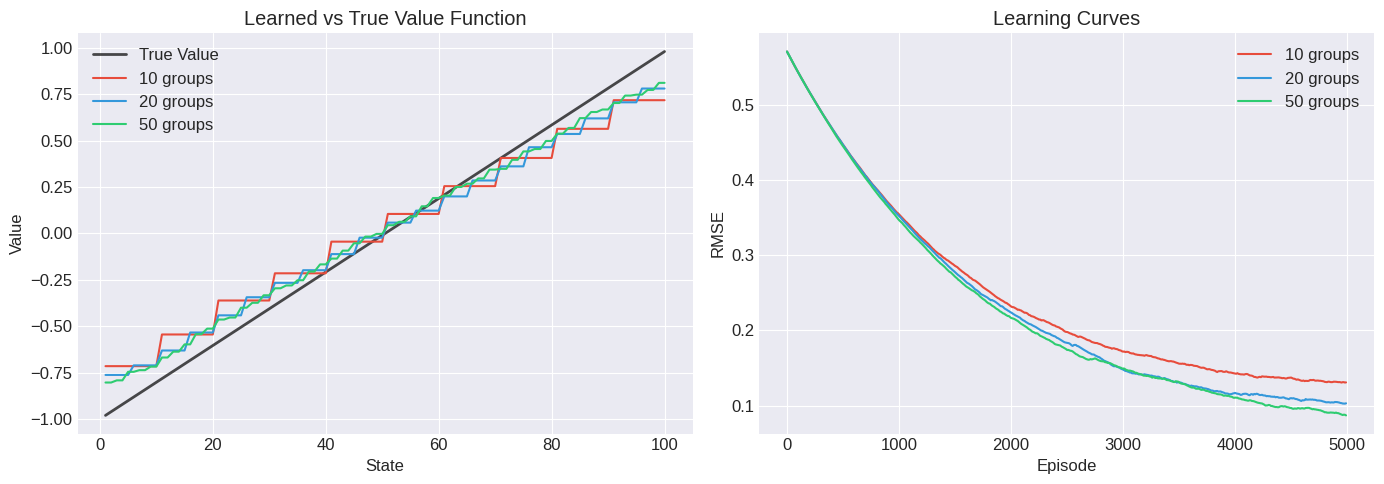

In [39]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot learned value functions
ax1 = axes[0]
states = np.arange(1, 101)
ax1.plot(states, true_values, 'k-', linewidth=2, label='True Value', alpha=0.7)

colors = ['#e74c3c', '#3498db', '#2ecc71', "b"]
for (n_groups, (agent, _)), color in zip(results.items(), colors):
    learned = np.array([agent.value(s) for s in states])
    ax1.plot(states, learned, color=color, linewidth=1.5, label=f'{n_groups} groups')

ax1.set_xlabel('State')
ax1.set_ylabel('Value')
ax1.set_title('Learned vs True Value Function')
ax1.legend()

# Plot learning curves
ax2 = axes[1]
for (n_groups, (_, errors)), color in zip(results.items(), colors):
    episodes = np.arange(0, len(errors) * 10, 10)
    ax2.plot(episodes, errors, color=color, linewidth=1.5, label=f'{n_groups} groups')

ax2.set_xlabel('Episode')
ax2.set_ylabel('RMSE')
ax2.set_title('Learning Curves')
ax2.legend()

plt.tight_layout()
plt.show()

---

# Part 2: The Deadly Triad — When Things Go Wrong (10 min)

## The Three Ingredients for Instability

The **deadly triad** refers to the combination of three elements that can cause learning to diverge:

1. **Function approximation** — Using a parameterized function instead of a table
2. **Bootstrapping** — Updating estimates based on other estimates (e.g., TD learning)
3. **Off-policy learning** — Learning about a policy different from the one generating data

When all three are present, learning can become **unstable** and values can diverge to infinity!

### Why Does This Happen?

- Function approximation introduces **generalization** — updating one state affects others
- Bootstrapping creates **self-referential updates** — we chase moving targets  
- Off-policy learning creates **distribution mismatch** — we sample from one distribution but optimize for another

---

## Demonstration: Baird's Counterexample

We'll implement a classic example showing divergence with off-policy TD learning.

### Understanding Off-Policy Learning

**Key concept:** In off-policy learning, we use data from a **behavior policy** $b$ to evaluate a **target policy** $\pi$.

- **Behavior policy $b$:** The policy we use to collect data (exploration)
- **Target policy $\pi$:** The policy we want to evaluate or improve

**Why off-policy?** 
- We might want to learn about a greedy policy while exploring with ε-greedy
- We might want to reuse old data (experience replay!)
- We might want to learn from demonstrations

**The catch:** We need **importance sampling** to correct for the distribution mismatch:
$$\rho = \frac{\pi(a|s)}{b(a|s)}$$

In Baird's example: The true value is $V(s) = 0$ everywhere, yet TD learning diverges!

In [14]:
class BairdCounterexample:
    """
    Baird's counterexample: A 7-state MDP where off-policy TD diverges.
    (Based on Sutton & Barto, Example 11.2)
    
    ┌─────────────────────────────────────────────────────────────────┐
    │  SETUP:                                                         │
    │  - 7 states: states 1-6 ("solid") and state 7 ("dashed")        │
    │  - From states 1-6: TWO actions available                       │
    │      • "dashed" action → deterministically goes to state 7      │
    │      • "solid" action → goes uniformly to one of states 1-6     │
    │  - From state 7: only one action, stays in state 7              │
    │  - All rewards = 0, so TRUE value V(s) = 0 for all s            │
    │  - gamma = 0.99                                                 │
    ├─────────────────────────────────────────────────────────────────┤
    │  POLICIES:                                                      │
    │  - Behavior policy b(a|s):                                      │
    │      • "dashed" action with prob 1/7                            │
    │      • "solid" action with prob 6/7                             │
    │  - Target policy π(a|s):                                        │
    │      • ALWAYS takes "dashed" action (prob = 1)                  │
    ├─────────────────────────────────────────────────────────────────┤
    │  KEY INSIGHT:                                                   │
    │  Under the TARGET policy π, the agent:                          │
    │    1. Takes "dashed" action → goes to state 7                   │
    │    2. Stays in state 7 forever                                  │
    │  So V^π(s) = 0 for ALL states! (trivial problem)                │
    │                                                                 │
    │  Yet semi-gradient TD DIVERGES trying to estimate V=0!          │
    ├─────────────────────────────────────────────────────────────────┤
    │  IMPORTANCE SAMPLING:                                           │
    │  We only update when "dashed" action is taken (goes to state 7) │
    │  ρ = π(dashed|s) / b(dashed|s) = 1 / (1/7) = 7 for states 1-6   │
    │  ρ = 1 for state 7 (only one action available)                  │
    └─────────────────────────────────────────────────────────────────┘
    """
    
    def __init__(self):
        self.n_states = 7
        self.gamma = 0.99
        
        # Feature matrix: 7 states × 8 features (from Sutton & Barto)
        # States 1-6: 2 in position i, 0 elsewhere, plus 1 in last position
        # State 7: 1s in positions 0-5, 2 in last position
        self.features = np.array([
            [2, 0, 0, 0, 0, 0, 0, 1],  # State 1
            [0, 2, 0, 0, 0, 0, 0, 1],  # State 2
            [0, 0, 2, 0, 0, 0, 0, 1],  # State 3
            [0, 0, 0, 2, 0, 0, 0, 1],  # State 4
            [0, 0, 0, 0, 2, 0, 0, 1],  # State 5
            [0, 0, 0, 0, 0, 2, 0, 1],  # State 6
            [1, 1, 1, 1, 1, 1, 1, 2],  # State 7 (dashed)
        ], dtype=np.float64)
        
        # Importance sampling ratio: ρ = π(a|s) / b(a|s)
        # We only consider updates when the "dashed" action is taken:
        # - States 1-6: ρ = π(dashed|s) / b(dashed|s) = 1 / (1/7) = 7
        # - State 7: only one action, so ρ = 1
        self.rho = np.array([7, 7, 7, 7, 7, 7, 1])
        
    def get_features(self, state: int) -> np.ndarray:
        """Get feature vector for state (0-indexed)."""
        return self.features[state]
    
    def sample_behavior(self) -> int:
        """Sample a state from the behavior policy distribution."""
        # Behavior: uniform over all states
        return np.random.randint(0, self.n_states)
    
    def next_state(self) -> int:
        """All actions lead to state 7 (index 6)."""
        return 6  # State 7 (0-indexed)

# Visualize the feature structure
baird = BairdCounterexample()
print("Feature matrix (states × features):")
print(baird.features)
print("\nImportance sampling ratios:", baird.rho)

Feature matrix (states × features):
[[2. 0. 0. 0. 0. 0. 0. 1.]
 [0. 2. 0. 0. 0. 0. 0. 1.]
 [0. 0. 2. 0. 0. 0. 0. 1.]
 [0. 0. 0. 2. 0. 0. 0. 1.]
 [0. 0. 0. 0. 2. 0. 0. 1.]
 [0. 0. 0. 0. 0. 2. 0. 1.]
 [1. 1. 1. 1. 1. 1. 1. 2.]]

Importance sampling ratios: [7 7 7 7 7 7 1]


## 🔴 Exercise 2.1: Observe Divergence

Run semi-gradient off-policy TD on Baird's counterexample and observe how the weights diverge.

**Advanced Question:** How can we change the code to prevent the divergence?

Diverged at step 92!


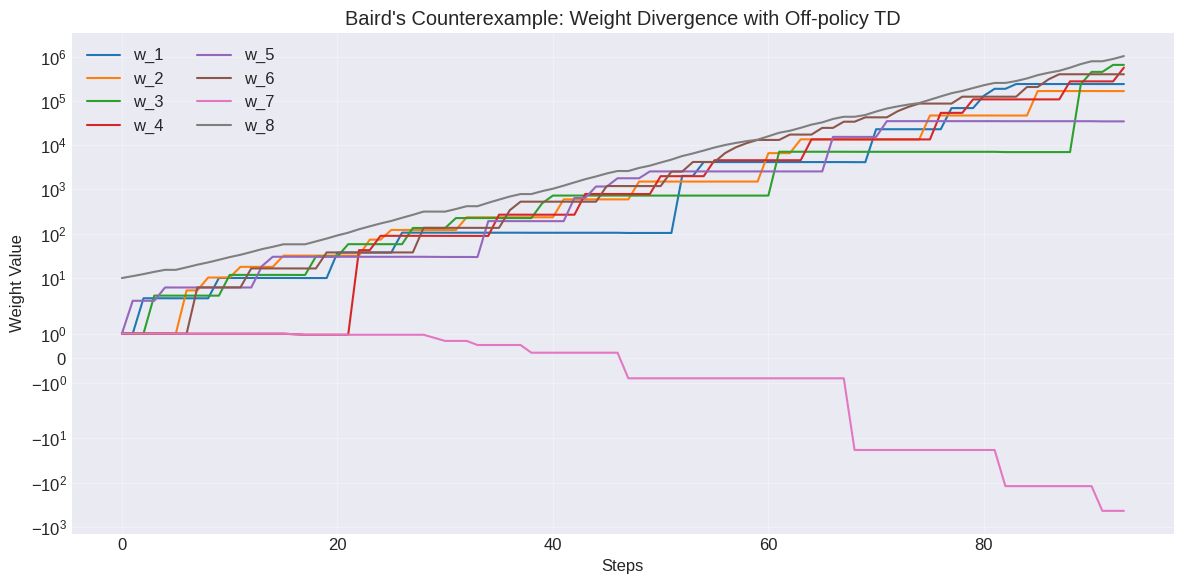


Final weights: [ 2.39142897e+05  1.65921756e+05  6.47882385e+05  5.62436638e+05
  3.43670577e+04  3.97682271e+05 -4.32560943e+02  1.02415706e+06]
Weight magnitude: 1424442.37


In [15]:
def run_baird_experiment(n_steps: int = 1000, alpha: float = 0.01):
    """Run off-policy semi-gradient TD on Baird's counterexample."""
    env = BairdCounterexample()
    
    # Initialize weights: w = [1, 1, 1, 1, 1, 1, 1, 10] as in the book
    w = np.array([1., 1., 1., 1., 1., 1., 1., 10.])
    
    weight_history = [w.copy()]
    
    for step in range(n_steps):
        # Sample state from behavior policy
        state = env.sample_behavior()
        next_state = env.next_state()
        reward = 0  # All rewards are 0
        
        # Get features
        x_s = env.get_features(state)
        x_next = env.get_features(next_state)
        
        # Compute TD error with importance sampling
        v_s = np.dot(w, x_s)
        v_next = np.dot(w, x_next)
        delta = reward + env.gamma * v_next - v_s
        
        # Off-policy correction (importance sampling ratio)
        rho = env.rho[state]
        
        # Semi-gradient TD update
        w = w + alpha * rho * delta * x_s
        
        weight_history.append(w.copy())
        
        # Stop if weights explode
        if np.max(np.abs(w)) > 1e6:
            print(f"Diverged at step {step}!")
            break
    
    return np.array(weight_history)

# Run experiment
weight_history = run_baird_experiment(n_steps=1000, alpha=0.01)

# Plot weight trajectories
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.plot(weight_history[:, i], label=f'w_{i+1}', linewidth=1.5)
    
plt.xlabel('Steps')
plt.ylabel('Weight Value')
plt.title("Baird's Counterexample: Weight Divergence with Off-policy TD")
plt.legend(loc='upper left', ncol=2)
plt.yscale('symlog')  # Symmetric log scale to show both positive and negative
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal weights: {weight_history[-1]}")
print(f"Weight magnitude: {np.linalg.norm(weight_history[-1]):.2f}")

### 💭 Discussion Question

**Q:** Why does the on-policy version (where behavior = target policy) NOT diverge?

**A:** In on-policy learning, we sample from the same distribution we're optimizing for. The state distribution under the behavior policy matches the target policy, so there's no distribution mismatch. The importance sampling ratios are all 1, and the updates remain bounded.

---

## Key Takeaway

The deadly triad is not just theoretical — it's a practical concern in deep RL! This motivates the **stabilization techniques** we'll explore in Parts 3 & 4.

---

# Part 3: Deep RL — Neural Network Function Approximation (20 min)

## From Linear to Nonlinear

Neural networks are **universal function approximators** — they can represent arbitrarily complex value functions:

$$\hat{v}(s, \boldsymbol{\theta}) = \text{NN}_\theta(s)$$

For action-value functions (Q-learning), we use:

$$\hat{q}(s, a, \boldsymbol{\theta}) = \text{NN}_\theta(s, a) \quad \text{or} \quad \hat{q}(s, \cdot, \boldsymbol{\theta}) = \text{NN}_\theta(s)$$

The second form outputs Q-values for all actions at once — more efficient!

---

## Environment: CartPole

We'll use the classic **CartPole** environment where:
- **State:** Cart position, cart velocity, pole angle, pole angular velocity (4D)
- **Actions:** Push left (0) or push right (1)
- **Reward:** +1 for each step the pole stays upright
- **Goal:** Keep the pole balanced for 500 steps

In [40]:
class CartPoleEnv:
    """
    Simple CartPole environment implementation.
    Based on OpenAI Gym's CartPole-v1.
    """
    
    def __init__(self):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.5  # Half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.tau = 0.02  # Time step
        
        # Thresholds for episode termination
        self.theta_threshold_radians = 12 * 2 * np.pi / 360  # ~12 degrees
        self.x_threshold = 2.4
        
        self.state = None
        self.steps = 0
        self.max_steps = 500
        
        # State and action space info
        self.state_dim = 4
        self.n_actions = 2
        
    def reset(self) -> np.ndarray:
        """Reset the environment."""
        self.state = np.random.uniform(-0.05, 0.05, size=(4,))
        self.steps = 0
        return self.state.copy()
    
    def step(self, action: int) -> Tuple[np.ndarray, float, bool]:
        """Take an action and return (next_state, reward, done)."""
        x, x_dot, theta, theta_dot = self.state
        
        force = self.force_mag if action == 1 else -self.force_mag
        costheta = np.cos(theta)
        sintheta = np.sin(theta)
        
        # Physics simulation
        temp = (force + self.polemass_length * theta_dot**2 * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (
            self.length * (4.0/3.0 - self.masspole * costheta**2 / self.total_mass)
        )
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass
        
        # Euler integration
        x = x + self.tau * x_dot
        x_dot = x_dot + self.tau * xacc
        theta = theta + self.tau * theta_dot
        theta_dot = theta_dot + self.tau * thetaacc
        
        self.state = np.array([x, x_dot, theta, theta_dot])
        self.steps += 1
        
        # Check termination
        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
            or self.steps >= self.max_steps
        )
        
        reward = 1.0 if not done or self.steps >= self.max_steps else 0.0
        
        return self.state.copy(), reward, done

# Test the environment
env = CartPoleEnv()
state = env.reset()
print(f"Initial state: {state}")
print(f"State dimension: {env.state_dim}, Actions: {env.n_actions}")

# Run a few random steps
total_reward = 0
done = False
while not done:
    action = np.random.randint(2)
    state, reward, done = env.step(action)
    total_reward += reward
print(f"Random policy episode reward: {total_reward}")

Initial state: [-0.00191826  0.02924713 -0.04914819  0.00423416]
State dimension: 4, Actions: 2
Random policy episode reward: 17.0


## 🔴 Exercise 3.1: Implement the Q-Network

Build a simple feedforward neural network that takes a state as input and outputs Q-values for all actions.

**Architecture:**
- Input: State vector (4D for CartPole)
- Hidden Layer 1: 128 units, ReLU activation
- Hidden Layer 2: 128 units, ReLU activation  
- Output: Q-values for each action (2 for CartPole)

In [41]:
class QNetwork(nn.Module):
    """
    Q-Network for DQN.
    Maps states to Q-values for all actions.
    """
    
    def __init__(self, state_dim: int, n_actions: int, hidden_dim: int = 128):
        super(QNetwork, self).__init__()
        
        # ============================================================
        # 🔴 TODO: Define the network layers
        # 
        # Create a network with:
        # - Linear layer: state_dim → hidden_dim
        # - ReLU activation
        # - Linear layer: hidden_dim → hidden_dim
        # - ReLU activation
        # - Linear layer: hidden_dim → n_actions
        # ============================================================
        
        # ✅ SOLUTION:
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )
        
    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        
        Args:
            state: Batch of states [batch_size, state_dim]
            
        Returns:
            Q-values for all actions [batch_size, n_actions]
        """
        return self.network(state)

# Test the network
test_net = QNetwork(state_dim=4, n_actions=2).to(device)
test_state = torch.randn(1, 4).to(device)
test_output = test_net(test_state)
print(f"Input shape: {test_state.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Q-values: {test_output.detach().cpu().numpy()}")

Input shape: torch.Size([1, 4])
Output shape: torch.Size([1, 2])
Q-values: [[ 0.01797955 -0.05614317]]


### Epsilon-Greedy Action Selection

For exploration, we use ε-greedy: with probability ε select random action, otherwise select greedy action.

**Advanced Question:** What other exploration method can we use for Q-network?

In [42]:
def select_action(q_net: QNetwork, state: np.ndarray, epsilon: float, n_actions: int) -> int:
    """
    Select action using epsilon-greedy policy.
    
    Args:
        q_net: Q-network
        state: Current state
        epsilon: Exploration probability
        n_actions: Number of actions
        
    Returns:
        Selected action
    """
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    else:
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = q_net(state_tensor)
            return q_values.argmax(dim=1).item()

### Naive DQN (Without Stabilization)

First, let's see what happens when we train a Q-network **without** any stabilization techniques. This demonstrates the instability caused by the deadly triad.

We run experiments across **multiple random seeds** to get a statistically meaningful comparison.

**To expose instability**, we use moderately aggressive hyperparameters:
- **Moderately high learning rate (2e-3):** Amplifies the effect of correlated sequential updates
- **Larger network:** More parameters = more prone to instability without stabilization
- **Longer training (500 episodes):** Gives enough time for instability to manifest

The goal is not to make DQN fail completely — it's to show that naive DQN **can partially learn** but remains **highly unstable** (oscillating, high variance across seeds), while the stabilized version learns consistently.

**Advanced Question:** Have a look at the code. Which exact conditions of deadly triad are satisfied here?

In [53]:
def set_seed(seed: int):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

class LargerQNetwork(nn.Module):
    """Larger Q-Network - more prone to instability without proper stabilization."""
    def __init__(self, state_dim: int, n_actions: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )
    
    def forward(self, x):
        return self.net(x)

def train_naive_dqn(n_episodes: int = 500, gamma: float = 0.99, 
                     lr: float = 1e-3, epsilon_start: float = 1.0, 
                     epsilon_end: float = 0.01, epsilon_decay: float = 0.995,
                     n_updates_per_step: int = 1, use_larger_network: bool = False,
                     seed: int = None, verbose: bool = True):
    """
    Train DQN WITHOUT stabilization (no experience replay, no target network).
    This demonstrates instability.
    
    Args:
        n_updates_per_step: Number of gradient updates per environment step (>1 amplifies instability)
        use_larger_network: Use a larger network (more prone to instability)
    """
    if seed is not None:
        set_seed(seed)
    
    env = CartPoleEnv()
    
    # Use larger network if specified (more prone to instability)
    if use_larger_network:
        q_net = LargerQNetwork(env.state_dim, env.n_actions).to(device)
    else:
        q_net = QNetwork(env.state_dim, env.n_actions).to(device)
    
    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    
    epsilon = epsilon_start
    episode_rewards = []
    losses = []
    q_magnitudes = []  # Track Q-value magnitudes for normalized loss
    
    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            # Select action
            action = select_action(q_net, state, epsilon, env.n_actions)
            
            # Take step
            next_state, reward, done = env.step(action)
            total_reward += reward
            
            # Multiple updates per step amplifies instability (correlated updates)
            for _ in range(n_updates_per_step):
                # Compute TD target (naive: no target network)
                with torch.no_grad():
                    next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)
                    next_q_values = q_net(next_state_tensor)
                    max_next_q = next_q_values.max(dim=1)[0]
                    target = reward + (1 - done) * gamma * max_next_q
                
                # Compute current Q-value
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = q_net(state_tensor)
                current_q = q_values[0, action]
                
                # Compute loss and update
                loss = F.mse_loss(current_q, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                # Track loss and Q-value magnitude for normalized loss computation
                losses.append(loss.item())
                q_magnitudes.append(abs(current_q.item()) + 1e-8)  # avoid division by zero
            
            state = next_state
        
        episode_rewards.append(total_reward)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        
        if verbose and (episode + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1}: Avg Reward = {avg_reward:.1f}, Epsilon = {epsilon:.3f}")
    
    return episode_rewards, losses, q_magnitudes

def run_naive_dqn_experiments(seeds: list, n_episodes: int = 300, **kwargs):
    """Run naive DQN experiments across multiple seeds."""
    all_rewards = []
    all_losses = []
    all_q_magnitudes = []
    
    for i, seed in enumerate(seeds):
        print(f"\n--- Naive DQN: Seed {seed} ({i+1}/{len(seeds)}) ---")
        rewards, losses, q_mags = train_naive_dqn(n_episodes=n_episodes, seed=seed, verbose=True, **kwargs)
        all_rewards.append(rewards)
        all_losses.append(losses)
        all_q_magnitudes.append(q_mags)
    
    return all_rewards, all_losses, all_q_magnitudes

# Configuration for multi-seed experiments
SEEDS = [42, 123, 456, 789, 1000]
N_EPISODES = 500

# Moderately aggressive settings to expose instability:
# - Moderately high learning rate (2e-3 vs 1e-3): amplifies correlated update issues
# - Standard gamma (0.99): keeps bootstrapping errors reasonable so agent can learn initially
# - Standard single update per step: isolates the effect of missing replay + target net
# - Larger network: more parameters = more prone to instability without stabilization
# - Standard epsilon decay: allows agent to explore enough to show partial learning

NAIVE_CONFIG = {
    'lr': 2e-3,              # Moderately high LR - enough to learn but causes oscillation
    'gamma': 0.995,           # Standard gamma - agent can learn initially
    'n_updates_per_step': 1, # Single update - isolates the replay/target-net effect
    'use_larger_network': True,  # More parameters = more instability without stabilization
    'epsilon_decay': 0.995,  # Standard decay - agent explores enough to show partial learning
}

# Train naive DQN across multiple seeds
print("Training Naive DQN (without stabilization) across multiple seeds...")
print(f"Config: lr={NAIVE_CONFIG['lr']}, gamma={NAIVE_CONFIG['gamma']}, "
      f"updates/step={NAIVE_CONFIG['n_updates_per_step']}, larger_net={NAIVE_CONFIG['use_larger_network']}")
naive_all_rewards, naive_all_losses, naive_all_q_mags = run_naive_dqn_experiments(SEEDS, N_EPISODES, **NAIVE_CONFIG)

Training Naive DQN (without stabilization) across multiple seeds...
Config: lr=0.002, gamma=0.995, updates/step=1, larger_net=True

--- Naive DQN: Seed 42 (1/5) ---
Episode 50: Avg Reward = 21.5, Epsilon = 0.778
Episode 100: Avg Reward = 34.0, Epsilon = 0.606
Episode 150: Avg Reward = 26.6, Epsilon = 0.471
Episode 200: Avg Reward = 43.3, Epsilon = 0.367
Episode 250: Avg Reward = 22.7, Epsilon = 0.286
Episode 300: Avg Reward = 10.5, Epsilon = 0.222
Episode 350: Avg Reward = 32.1, Epsilon = 0.173
Episode 400: Avg Reward = 17.2, Epsilon = 0.135
Episode 450: Avg Reward = 49.8, Epsilon = 0.105
Episode 500: Avg Reward = 66.8, Epsilon = 0.082

--- Naive DQN: Seed 123 (2/5) ---
Episode 50: Avg Reward = 20.1, Epsilon = 0.778
Episode 100: Avg Reward = 31.3, Epsilon = 0.606
Episode 150: Avg Reward = 38.1, Epsilon = 0.471
Episode 200: Avg Reward = 56.8, Epsilon = 0.367
Episode 250: Avg Reward = 133.0, Epsilon = 0.286
Episode 300: Avg Reward = 196.4, Epsilon = 0.222
Episode 350: Avg Reward = 138.1,

---

# Part 4: Stabilization Methods (15 min)

## Breaking the Deadly Triad

To make deep RL work, we need techniques to stabilize training. The two key innovations from DQN (Mnih et al., 2015) are:

### 1. Experience Replay

**Problem:** Consecutive samples are highly correlated → biased gradients

**Solution:** Store transitions in a **replay buffer** and sample random mini-batches
- Breaks temporal correlations
- Reuses data efficiently
- Smooths out the data distribution

### 2. Target Network

**Problem:** Bootstrapping from a changing network → chasing a moving target

**Solution:** Use a separate **target network** for computing TD targets
- Target network parameters are updated slowly (every N steps)
- Provides stable targets during learning
- Reduces oscillations and divergence

**Advanced Question:** How exactly does DQN change the conditions of deadly triad?

---

## 🔴 Exercise 4.1: Implement Experience Replay

Create a replay buffer that stores transitions and samples random mini-batches.

In [44]:
# Named tuple for storing transitions
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    """Experience replay buffer for DQN."""
    
    def __init__(self, capacity: int = 10000):
        self.buffer = deque(maxlen=capacity)
        
    def push(self, state: np.ndarray, action: int, reward: float, 
             next_state: np.ndarray, done: bool):
        """Add a transition to the buffer."""
        self.buffer.append(Transition(state, action, reward, next_state, done))
    
    def sample(self, batch_size: int) -> Tuple[torch.Tensor, ...]:
        """
        Sample a random batch of transitions.
        
        Returns:
            Tuple of (states, actions, rewards, next_states, dones) as tensors
        """
        # ============================================================
        # 🔴 TODO: Implement batch sampling
        # 
        # Steps:
        # 1. Randomly sample batch_size transitions from buffer
        # 2. Unzip into separate lists (states, actions, etc.)
        # 3. Convert to PyTorch tensors and move to device
        # ============================================================
        
        # ✅ SOLUTION:
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        
        states = torch.FloatTensor(np.array(batch.state)).to(device)
        actions = torch.LongTensor(batch.action).to(device)
        rewards = torch.FloatTensor(batch.reward).to(device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(device)
        dones = torch.FloatTensor(batch.done).to(device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self) -> int:
        return len(self.buffer)

# Test replay buffer
buffer = ReplayBuffer(capacity=100)
env = CartPoleEnv()
state = env.reset()

# Fill with some transitions
for _ in range(100):
    action = np.random.randint(2)
    next_state, reward, done = env.step(action)
    buffer.push(state, action, reward, next_state, done)
    state = next_state if not done else env.reset()

# Test sampling
states, actions, rewards, next_states, dones = buffer.sample(32)
print(f"Buffer size: {len(buffer)}")
print(f"Batch shapes: states={states.shape}, actions={actions.shape}")

Buffer size: 100
Batch shapes: states=torch.Size([32, 4]), actions=torch.Size([32])


## 🔴 Exercise 4.2: Implement Full DQN Agent

Now combine everything: Q-Network, Experience Replay, and Target Network.

In [45]:
class DQNAgent:
    """
    Full DQN Agent with experience replay and target network.
    """
    
    def __init__(self, state_dim: int, n_actions: int, 
                 lr: float = 1e-3, gamma: float = 0.99,
                 buffer_size: int = 10000, batch_size: int = 64,
                 target_update_freq: int = 100,
                 use_larger_network: bool = False):
        
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        
        # Q-Network and Target Network (use larger network if specified)
        NetworkClass = LargerQNetwork if use_larger_network else QNetwork
        self.q_net = NetworkClass(state_dim, n_actions).to(device)
        self.target_net = NetworkClass(state_dim, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()  # Target network is not trained directly
        
        # Optimizer and replay buffer
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)
        
        self.update_count = 0
        
    def select_action(self, state: np.ndarray, epsilon: float) -> int:
        """Select action using epsilon-greedy."""
        if np.random.random() < epsilon:
            return np.random.randint(self.n_actions)
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.q_net(state_tensor)
                return q_values.argmax(dim=1).item()
    
    def store_transition(self, state, action, reward, next_state, done):
        """Store transition in replay buffer."""
        self.buffer.push(state, action, reward, next_state, done)
    
    def update(self) -> Optional[tuple]:
        """
        Perform one gradient update step.
        
        Returns:
            Tuple of (loss, avg_q_magnitude) or None if buffer too small
        """
        if len(self.buffer) < self.batch_size:
            return None
        
        # ============================================================
        # 🔴 TODO: Implement the DQN update step
        # 
        # Steps:
        # 1. Sample a batch from replay buffer
        # 2. Compute current Q-values: Q(s, a) for the taken actions
        # 3. Compute target Q-values using TARGET network:
        #    target = r + gamma * max_a' Q_target(s', a') * (1 - done)
        # 4. Compute MSE loss between current and target
        # 5. Backpropagate and update
        # 6. Periodically update target network
        # ============================================================
        
        # ✅ SOLUTION:
        # Sample batch
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        
        # Current Q-values
        current_q = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        # Track Q-value magnitude for normalized loss
        avg_q_magnitude = current_q.abs().mean().item() + 1e-8
        
        # Target Q-values (using target network!)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones)
        
        # Compute loss and update
        loss = F.mse_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network periodically
        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        return loss.item(), avg_q_magnitude

### Training the Full DQN

Let's train the stabilized DQN using the **same random seeds** AND the **same hyperparameters** as the naive version. This demonstrates that experience replay and target networks produce consistent, stable learning — while the naive version oscillates and shows high variance across seeds.

In [54]:
def train_dqn(n_episodes: int = 500, epsilon_start: float = 1.0,
              epsilon_end: float = 0.01, epsilon_decay: float = 0.995,
              lr: float = 1e-3, gamma: float = 0.99,
              use_larger_network: bool = False,
              seed: int = None, verbose: bool = True):
    """Train full DQN with stabilization techniques."""
    if seed is not None:
        set_seed(seed)
    
    env = CartPoleEnv()
    agent = DQNAgent(
        state_dim=env.state_dim,
        n_actions=env.n_actions,
        lr=lr,
        gamma=gamma,
        buffer_size=10000,
        # buffer_size=3000,
        batch_size=64,
        target_update_freq=50,
        use_larger_network=use_larger_network
    )
    
    epsilon = epsilon_start
    episode_rewards = []
    losses = []
    q_magnitudes = []  # Track Q-value magnitudes for normalized loss
    
    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        episode_loss = []
        episode_q_mag = []
        
        while not done:
            # Select action
            action = agent.select_action(state, epsilon)
            
            # Take step
            next_state, reward, done = env.step(action)
            total_reward += reward
            
            # Store and learn
            agent.store_transition(state, action, reward, next_state, done)
            result = agent.update()
            if result is not None:
                loss, q_mag = result
                episode_loss.append(loss)
                episode_q_mag.append(q_mag)
            
            state = next_state
        
        episode_rewards.append(total_reward)
        if episode_loss:
            losses.append(np.mean(episode_loss))
            q_magnitudes.append(np.mean(episode_q_mag))
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        
        if verbose and (episode + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1}: Avg Reward = {avg_reward:.1f}, Epsilon = {epsilon:.3f}")
    
    return episode_rewards, losses, q_magnitudes, agent

def run_dqn_experiments(seeds: list, n_episodes: int = 300, **kwargs):
    """Run stabilized DQN experiments across multiple seeds."""
    all_rewards = []
    all_losses = []
    all_q_magnitudes = []
    trained_agents = []
    
    for i, seed in enumerate(seeds):
        print(f"\n--- Stabilized DQN: Seed {seed} ({i+1}/{len(seeds)}) ---")
        rewards, losses, q_mags, agent = train_dqn(n_episodes=n_episodes, seed=seed, verbose=True, **kwargs)
        all_rewards.append(rewards)
        all_losses.append(losses)
        all_q_magnitudes.append(q_mags)
        trained_agents.append(agent)
    
    return all_rewards, all_losses, all_q_magnitudes, trained_agents

# Use the SAME settings as naive DQN for fair comparison
# The stabilization techniques should handle these settings much better!
STABLE_CONFIG = {
    'lr': NAIVE_CONFIG['lr'],              # Same LR
    'gamma': NAIVE_CONFIG['gamma'],        # Same gamma
    'use_larger_network': NAIVE_CONFIG['use_larger_network'],  # Same network size
    'epsilon_decay': NAIVE_CONFIG['epsilon_decay'],  # Same epsilon decay
}

# Train full DQN across multiple seeds (using same seeds as naive DQN)
print("Training DQN with Stabilization (Experience Replay + Target Network) across multiple seeds...")
print(f"Config: lr={STABLE_CONFIG['lr']}, gamma={STABLE_CONFIG['gamma']}, larger_net={STABLE_CONFIG['use_larger_network']}")
print("(Same settings as naive - but WITH stabilization!)")
dqn_all_rewards, dqn_all_losses, dqn_all_q_mags, trained_agents = run_dqn_experiments(SEEDS, N_EPISODES, **STABLE_CONFIG)

# Keep the best agent for later evaluation
best_idx = np.argmax([np.mean(r[-50:]) for r in dqn_all_rewards])
trained_agent = trained_agents[best_idx]
print(f"\nBest agent from seed {SEEDS[best_idx]} with avg reward: {np.mean(dqn_all_rewards[best_idx][-50:]):.1f}")

Training DQN with Stabilization (Experience Replay + Target Network) across multiple seeds...
Config: lr=0.002, gamma=0.995, larger_net=True
(Same settings as naive - but WITH stabilization!)

--- Stabilized DQN: Seed 42 (1/5) ---
Episode 50: Avg Reward = 23.9, Epsilon = 0.778
Episode 100: Avg Reward = 33.0, Epsilon = 0.606
Episode 150: Avg Reward = 32.6, Epsilon = 0.471
Episode 200: Avg Reward = 59.9, Epsilon = 0.367
Episode 250: Avg Reward = 129.9, Epsilon = 0.286
Episode 300: Avg Reward = 121.1, Epsilon = 0.222
Episode 350: Avg Reward = 279.9, Epsilon = 0.173
Episode 400: Avg Reward = 256.3, Epsilon = 0.135
Episode 450: Avg Reward = 199.9, Epsilon = 0.105
Episode 500: Avg Reward = 405.3, Epsilon = 0.082

--- Stabilized DQN: Seed 123 (2/5) ---
Episode 50: Avg Reward = 24.7, Epsilon = 0.778
Episode 100: Avg Reward = 30.3, Epsilon = 0.606
Episode 150: Avg Reward = 51.7, Epsilon = 0.471
Episode 200: Avg Reward = 53.7, Epsilon = 0.367
Episode 250: Avg Reward = 122.5, Epsilon = 0.286
Epis

### Comparison: Naive vs. Stabilized DQN (Multi-Seed)

Let's visualize the difference in learning stability across multiple random seeds. The shaded regions show the standard deviation across seeds, giving us a better sense of the variability and reliability of each approach.

**About the Normalized Loss Plot:**
Raw MSE loss in DQN typically *increases* during successful training because Q-values grow larger as the agent learns to predict higher returns. To see actual learning progress, we show **normalized loss** = √(loss) / |Q|, which measures the TD error relative to Q-value magnitude. This metric should *decrease* as the agent learns, similar to supervised learning loss.

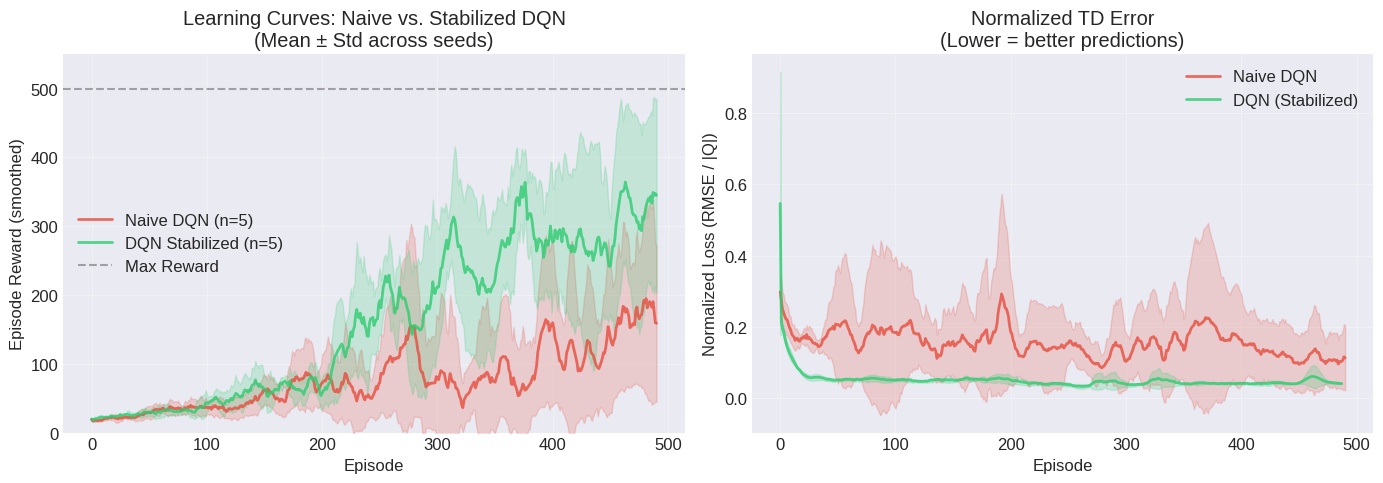


FINAL RESULTS (across 5 seeds: [42, 123, 456, 789, 1000])
Naive DQN - Last 50 episodes avg: 163.0 ± 104.3
Full DQN  - Last 50 episodes avg: 314.8 ± 96.2

Per-seed breakdown:
----------------------------------------
  Seed 42: Naive = 66.8, Stabilized = 405.3
  Seed 123: Naive = 254.6, Stabilized = 338.4
  Seed 456: Naive = 297.0, Stabilized = 425.3
  Seed 789: Naive = 170.6, Stabilized = 194.4
  Seed 1000: Naive = 26.1, Stabilized = 210.8


In [55]:
def smooth(data, window=10):
    """Smooth data with moving average."""
    return np.convolve(data, np.ones(window)/window, mode='valid')

def compute_mean_std(all_runs, window=10):
    """Compute mean and std across multiple runs after smoothing."""
    # Smooth each run
    smoothed_runs = [smooth(run, window) for run in all_runs]
    # Find minimum length (they should be same, but just in case)
    min_len = min(len(run) for run in smoothed_runs)
    # Truncate to same length
    smoothed_runs = [run[:min_len] for run in smoothed_runs]
    # Stack and compute statistics
    stacked = np.array(smoothed_runs)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0)
    return mean, std

def plot_with_confidence(ax, mean, std, color, label, alpha_line=0.8, alpha_fill=0.2):
    """Plot mean with shaded standard deviation region."""
    x = np.arange(len(mean))
    ax.plot(x, mean, color=color, linewidth=2, label=label, alpha=alpha_line)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=alpha_fill)

def compute_normalized_loss(all_losses, all_q_mags, n_episodes):
    """
    Compute normalized loss: sqrt(MSE) / |Q| = RMSE / Q-magnitude.
    This gives a scale-invariant measure of prediction error.
    """
    normalized_list = []
    for losses, q_mags in zip(all_losses, all_q_mags):
        # For naive DQN: losses are step-wise, need to aggregate to episodes
        if len(losses) > n_episodes * 2:  # Step-wise losses
            steps_per_ep = len(losses) // n_episodes
            ep_losses = [np.mean(losses[i*steps_per_ep:(i+1)*steps_per_ep]) 
                        for i in range(n_episodes) if (i+1)*steps_per_ep <= len(losses)]
            ep_q_mags = [np.mean(q_mags[i*steps_per_ep:(i+1)*steps_per_ep]) 
                        for i in range(n_episodes) if (i+1)*steps_per_ep <= len(q_mags)]
        else:  # Already episode-wise
            ep_losses = losses
            ep_q_mags = q_mags
        
        # Compute normalized loss: RMSE / Q-magnitude
        min_len = min(len(ep_losses), len(ep_q_mags))
        normalized = [np.sqrt(l) / q for l, q in zip(ep_losses[:min_len], ep_q_mags[:min_len])]
        normalized_list.append(normalized)
    
    return normalized_list

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compute statistics for rewards
naive_mean, naive_std = compute_mean_std(naive_all_rewards, window=10)
dqn_mean, dqn_std = compute_mean_std(dqn_all_rewards, window=10)

# Plot episode rewards with confidence bands
ax1 = axes[0]
plot_with_confidence(ax1, naive_mean, naive_std, '#e74c3c', f'Naive DQN (n={len(SEEDS)})')
plot_with_confidence(ax1, dqn_mean, dqn_std, '#2ecc71', f'DQN Stabilized (n={len(SEEDS)})')
ax1.axhline(y=500, color='gray', linestyle='--', label='Max Reward', alpha=0.7)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Episode Reward (smoothed)')
ax1.set_title('Learning Curves: Naive vs. Stabilized DQN\n(Mean ± Std across seeds)')
ax1.legend()
ax1.set_ylim([0, 550])
ax1.grid(True, alpha=0.3)

# Compute NORMALIZED loss: sqrt(loss) / Q-magnitude
# This metric should DECREASE as learning progresses (unlike raw MSE)
naive_normalized = compute_normalized_loss(naive_all_losses, naive_all_q_mags, N_EPISODES)
dqn_normalized = compute_normalized_loss(dqn_all_losses, dqn_all_q_mags, N_EPISODES)

naive_norm_mean, naive_norm_std = compute_mean_std(naive_normalized, window=10)
dqn_norm_mean, dqn_norm_std = compute_mean_std(dqn_normalized, window=10)

# Plot normalized loss comparison
ax2 = axes[1]
plot_with_confidence(ax2, naive_norm_mean, naive_norm_std, '#e74c3c', 'Naive DQN')
plot_with_confidence(ax2, dqn_norm_mean, dqn_norm_std, '#2ecc71', 'DQN (Stabilized)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Normalized Loss (RMSE / |Q|)')
ax2.set_title('Normalized TD Error\n(Lower = better predictions)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics across all seeds
print("\n" + "="*60)
print("FINAL RESULTS (across {} seeds: {})".format(len(SEEDS), SEEDS))
print("="*60)

naive_final = [np.mean(r[-50:]) for r in naive_all_rewards]
dqn_final = [np.mean(r[-50:]) for r in dqn_all_rewards]

print(f"Naive DQN - Last 50 episodes avg: {np.mean(naive_final):.1f} ± {np.std(naive_final):.1f}")
print(f"Full DQN  - Last 50 episodes avg: {np.mean(dqn_final):.1f} ± {np.std(dqn_final):.1f}")
print()
print("Per-seed breakdown:")
print("-" * 40)
for i, seed in enumerate(SEEDS):
    print(f"  Seed {seed}: Naive = {naive_final[i]:.1f}, Stabilized = {dqn_final[i]:.1f}")

### Evaluate Trained Agent

Let's see our trained DQN in action!

Evaluation over 20 episodes:
  Mean Reward: 249.7
  Std Reward:  4.7
  Min/Max:     241 / 256


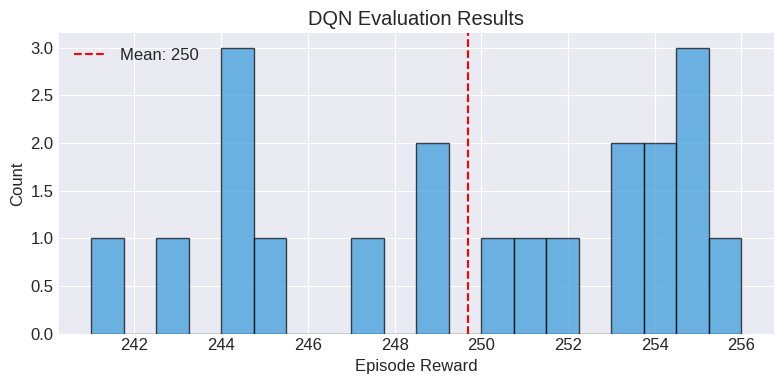

In [56]:
def evaluate_agent(agent: DQNAgent, n_episodes: int = 10):
    """Evaluate agent with greedy policy (epsilon=0)."""
    env = CartPoleEnv()
    rewards = []
    
    for _ in range(n_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state, epsilon=0.0)  # Greedy
            state, reward, done = env.step(action)
            total_reward += reward
        
        rewards.append(total_reward)
    
    return rewards

# Evaluate
eval_rewards = evaluate_agent(trained_agent, n_episodes=20)
print(f"Evaluation over 20 episodes:")
print(f"  Mean Reward: {np.mean(eval_rewards):.1f}")
print(f"  Std Reward:  {np.std(eval_rewards):.1f}")
print(f"  Min/Max:     {np.min(eval_rewards):.0f} / {np.max(eval_rewards):.0f}")

# Histogram
plt.figure(figsize=(8, 4))
plt.hist(eval_rewards, bins=20, edgecolor='black', alpha=0.7, color='#3498db')
plt.axvline(x=np.mean(eval_rewards), color='red', linestyle='--', 
            label=f'Mean: {np.mean(eval_rewards):.0f}')
plt.xlabel('Episode Reward')
plt.ylabel('Count')
plt.title('DQN Evaluation Results')
plt.legend()
plt.tight_layout()
plt.show()

---

# Summary

## Key Takeaways

### 1. Linear Function Approximation
- Use feature vectors $\mathbf{x}(s)$ to represent states
- Semi-gradient TD: $\mathbf{w} \leftarrow \mathbf{w} + \alpha \delta \nabla_\mathbf{w} \hat{v}(S, \mathbf{w})$
- **Converges** for on-policy learning with linear features

### 2. The Deadly Triad
- **Function approximation** + **Bootstrapping** + **Off-policy** = Potential divergence
- Even simple examples (Baird's counterexample) can diverge
- This is a fundamental challenge in deep RL

### 3. Deep RL Stabilization
- **Experience Replay:** Break correlations, reuse data
- **Target Network:** Stabilize bootstrap targets
- DQN (2015) showed these techniques enable training on high-dimensional inputs

---

## 🎯 Bonus Challenges (Optional)

If you finish early, try these extensions:

1. **Double DQN:** Reduce overestimation by decoupling action selection and evaluation
2. **Dueling DQN:** Separate value and advantage streams
3. **Prioritized Replay:** Sample important transitions more often
4. **Gradient Clipping:** Add gradient clipping to prevent exploding gradients

---

## References

- Sutton & Barto (2018). *Reinforcement Learning: An Introduction*, Chapter 9-11
- Mnih et al. (2015). *Human-level control through deep reinforcement learning*. Nature
- Baird (1995). *Residual Algorithms: Reinforcement Learning with Function Approximation*

---

**Congratulations!** You've completed the function approximation exercises. 🎉